In [4]:
import os
import re
import json
import time
import html
import requests
import pandas as pd

# Скачивание данных с Яндекс Метрики

In [42]:
# счетчик гб
counter_id = 87420409

In [43]:
# все необходимео для авторизации
oauth_token = 'y0__xC22upLGJLmOiDu3s3TFJqoY6TczWleJl4Dg_l00Cqy79ar'
headers = {
    'Authorization': f'OAuth {oauth_token}', 
    'Content-Type': 'application/x-yametrika+json'
}

In [7]:
columns = ['ym:s:clientID', 'ym:s:impressionsDateTime', 'ym:s:impressionsProductName']
fields = ','.join(columns)

## Подготовка
Нельзя выгрузить данные более, чем за один год. Поэтому придется разбить загрузку по годам.

In [25]:
# оценка возможности выгрузки
def evaluate(date1, date2):
    url = f'https://api-metrika.yandex.net/management/v1/counter/{counter_id}/logrequests/evaluate'
    params = {
        'date1': date1,
        'date2': date2,
        'fields': fields,
        'source': 'visits'
    }
    r = requests.get(url, params=params, headers=headers)
    response = json.loads(r.content.decode('utf-8'))
    print(response)
    
    request_id = None
    if response['log_request_evaluation']['possible'] == True:
        # запрос на выгрузку
        url = f'https://api-metrika.yandex.net/management/v1/counter/{counter_id}/logrequests'
        r = requests.post(url, params=params, headers=headers)
        response = json.loads(r.content.decode('utf-8'))
        request_id = response['log_request']['request_id']
        print(f'request ID: {request_id}')
    return request_id


In [31]:
# ожидание выполнения, скачивание и удаление выгрузки
def download_and_clean(request_id):
    downloaded = False
    request = None
    status = None
    
    partsNum = 0
    files = []
    if request_id is not None:
        url = f'https://api-metrika.yandex.net/management/v1/counter/{counter_id}/logrequests'
        r = requests.get(url, headers=headers)
        status = json.loads(r.content.decode('utf-8'))
        for r in status['requests']:
            if r['request_id'] != request_id:
                continue
            request = r
            print(request)
            partsNum = len(r['parts'])
            break
    
    if request and request['status'] == 'processed':
        for i in range(0, partsNum):
            url = f'https://api-metrika.yandex.net/management/v1/counter/{counter_id}/logrequest/{request_id}/part/{i}/download'
            r = requests.get(url, headers=headers)
            content = r.content.decode('utf-8')
            
            file_name = f'{request_id}-part{i}.csv'
            with open(file_name, 'w') as f:
                f.write(content)
            print(f'part {i} downloaded and writed to file {file_name}')
            files.append(file_name)
        downloaded = True
    
    if downloaded:
        url = f'https://api-metrika.yandex.net/management/v1/counter/{counter_id}/logrequest/{request_id}/clean'
        r = requests.post(url, headers=headers)
        print(r.content)
        downloaded = False
        print(f'{request_id} cleaned!')
    return files
    

## Скачивание данных из Я.Метрики

In [30]:
fp = []

In [32]:
#r1 = evaluate('2023-01-01', '2024-01-01')
#time.sleep(30)
#fp += download_and_clean(r1)

{'log_request_evaluation': {'possible': True, 'expected_size': 16410036, 'max_possible_day_quantity': 238778, 'log_request_sum_max_size': 10737418240, 'log_request_sum_size': 31500604}}
request ID: 47543960
{'request_id': 47543960, 'counter_id': 87420409, 'source': 'visits', 'date1': '2023-01-01', 'date2': '2024-01-01', 'fields': ['ym:s:clientID', 'ym:s:impressionsDateTime', 'ym:s:impressionsProductName'], 'status': 'processed', 'size': 16191285, 'parts': [{'part_number': 0, 'size': 16191285}], 'attribution': 'LASTSIGN'}
part 0 downloaded and writed to file 47543960-part0.csv
b'{"log_request":{"request_id":47543960,"counter_id":87420409,"source":"visits","date1":"2023-01-01","date2":"2024-01-01","fields":["ym:s:clientID","ym:s:impressionsDateTime","ym:s:impressionsProductName"],"status":"cleaned_by_user","size":16191285,"parts":[{"part_number":0,"size":16191285}],"attribution":"LASTSIGN"}}'
47543960 cleaned!


In [34]:
# r2 = evaluate('2024-01-02', '2025-01-01')
# time.sleep(35)
#fp += download_and_clean(r2)

{'request_id': 47543978, 'counter_id': 87420409, 'source': 'visits', 'date1': '2024-01-02', 'date2': '2025-01-01', 'fields': ['ym:s:clientID', 'ym:s:impressionsDateTime', 'ym:s:impressionsProductName'], 'status': 'processed', 'size': 25640520, 'parts': [{'part_number': 0, 'size': 25640520}], 'attribution': 'LASTSIGN'}
part 0 downloaded and writed to file 47543978-part0.csv
b'{"log_request":{"request_id":47543978,"counter_id":87420409,"source":"visits","date1":"2024-01-02","date2":"2025-01-01","fields":["ym:s:clientID","ym:s:impressionsDateTime","ym:s:impressionsProductName"],"status":"cleaned_by_user","size":25640520,"parts":[{"part_number":0,"size":25640520}],"attribution":"LASTSIGN"}}'
47543978 cleaned!


In [35]:
#r3 = evaluate('2025-01-02', '2025-10-11')
#time.sleep(35)
#fp += download_and_clean(r3)

{'log_request_evaluation': {'possible': True, 'expected_size': 11040185, 'max_possible_day_quantity': 274431, 'log_request_sum_max_size': 10737418240, 'log_request_sum_size': 31500604}}
request ID: 47543996
{'request_id': 47543996, 'counter_id': 87420409, 'source': 'visits', 'date1': '2025-01-02', 'date2': '2025-10-11', 'fields': ['ym:s:clientID', 'ym:s:impressionsDateTime', 'ym:s:impressionsProductName'], 'status': 'processed', 'size': 21078033, 'parts': [{'part_number': 0, 'size': 21078033}], 'attribution': 'LASTSIGN'}
part 0 downloaded and writed to file 47543996-part0.csv
b'{"log_request":{"request_id":47543996,"counter_id":87420409,"source":"visits","date1":"2025-01-02","date2":"2025-10-11","fields":["ym:s:clientID","ym:s:impressionsDateTime","ym:s:impressionsProductName"],"status":"cleaned_by_user","size":21078033,"parts":[{"part_number":0,"size":21078033}],"attribution":"LASTSIGN"}}'
47543996 cleaned!


In [36]:
fp

['47543960-part0.csv', '47543978-part0.csv', '47543996-part0.csv']

## Объединение скачаннах данных

In [5]:
merged_csv_file_path = './04-metrika-pipeline-20230101-20251011.csv'

In [39]:
merged = pd.read_csv(f'./{fp[0]}', delimiter='\t')
print(merged.shape)
for filename in fp[1:]:
    df = pd.read_csv(f'./{filename}', delimiter='\t')
    print(df.shape)
    merged = pd.concat([merged, df])
    print(merged.shape)

merged.sample(5)

(527584, 3)
(483257, 3)
(1010841, 3)
(351388, 3)
(1362229, 3)


,ym:s:clientID,ym:s:impressionsDateTime,ym:s:impressionsProductName
20973,1734989879560580932,[\'2024-12-24 00:37:59\'],['Resident Evil 4']
128181,1718006137115348110,[\'2024-06-10 10:55:37\'],['Manor Lords']
232689,170550805484953691,[],[]
205183,1741896220964409205,[],[]
43871,171614409927710637,[\'2024-05-19 21:41:38\'],['Ghost of Tsushima DIRECTOR&#x27;S CUT']


In [ ]:
merged.to_csv(merged_csv_file_path)
for filename in fp:
    os.remove(filename)

# Обработка и сбор датасетов

## Обработка объединенных данных

In [8]:
# загрузка файла в dataframe
df = pd.read_csv(merged_csv_file_path)[columns]
df.sample(3)

,ym:s:clientID,ym:s:impressionsDateTime,ym:s:impressionsProductName
72635,1701924628462224628,[],[]
1317383,1755259428669038340,[],[]
990383,1700824698590966806,"[\'2024-04-11 08:27:18\',\'2024-04-11 08:44:36...","['Dead Cells','Dead Cells','Dead Cells']"


In [9]:
print(f'Записей: {df.shape[0]}, уникальных клиентов в них: {len(df['ym:s:clientID'].unique())}')

Записей: 1362229, уникальных клиентов в них: 961368


In [10]:
# выкидываем все пустые записи
df = df[(df['ym:s:impressionsDateTime'] != '[]')]
print(f'Записей: {df.shape[0]}, уникальных клиентов в них: {len(df['ym:s:clientID'].unique())}')

Записей: 302003, уникальных клиентов в них: 207838


Обходим все данные и пересобираем их:
- в рамках каждого клиента убираем повторные посещения
- считаем карту встречаемости игр (карта посещений, пригодится впоследствии для ранжирования)

In [11]:
%%time
client_products_uniq = {} # карта уникальных продуктов для клиента
products_views = {} # карта просмотров продуктов 
data = [] # данные для датасета

for i, row in df.iterrows():
    dates = re.sub(r'[\'\[\]\\]', '', row['ym:s:impressionsDateTime']).split(',')
    names = re.sub(r'[\[\]\\]', '', row['ym:s:impressionsProductName']).split("','")

    if len(names) != len(dates):
        print(f'names len {len(names)} != dates len {len(dates)}')
        print(row['ym:s:impressionsDateTime'])
        print(row['ym:s:impressionsProductName'])
        break

    client_id = row['ym:s:clientID']
    if client_id not in client_products_uniq:
        client_products_uniq[client_id] = set()
    
    # ожидаем, что список dates и names равны по длине
    for i in range(0, len(names)):
        date = dates[i]
        name = re.sub(r'[\']', '', names[i])

        # перекодировать русские и спец.символы
        name = html.unescape(name)
        
        # инкремент счетчика посещения игры
        if name not in products_views:
            products_views[name] = 0
        products_views[name] += 1
        
        if name in client_products_uniq[client_id]:
            # клиент ранее уже посещал страницу игры, игнорируем
            continue
        
        data.append([client_id, date, name])
        # фиксируем, что клиент посетил игру
        client_products_uniq[client_id].add(names[i])

CPU times: user 12.5 s, sys: 80.2 ms, total: 12.6 s
Wall time: 12.6 s


## Датасет кол-ва просмотров игры клиентами

In [99]:
cols = ['productName', 'views']
df_products = pd.DataFrame(products_views.items(), columns=cols).set_index('productName')

In [100]:
df_products = df_products.sort_values(by='views', ascending=False)

In [101]:
# top-10 посещеных игр на сайте с 2023-01-01
df_products.head(10)

,views
productName,
Manor Lords,19475
Hello Neighbor,9637
HELLDIVERS™ 2,7936
Kingdom Come: Deliverance II,5314
Ghost of Tsushima DIRECTOR'S CUT,4577
RoboCop: Rogue City,4364
Monster Hunter Wilds,4340
Farming Simulator 25 – Year 1 Bundle,4106
ELDEN RING - Shadow of the Erdtree,3851


In [102]:
df_products.shape

(8044, 1)

In [103]:
df_products.to_csv('./04-metrika-pipeline-products-views.csv')

Тут 8044 наименования. При этом я предполагаю:
- что не на все карточки заходили за это время
- что некоторые игры уже недоступны на сайте ГБ

## Датасет для тестирования рексис
Или просто Датасет

In [12]:
df_dataset = pd.DataFrame(data, columns=['clientId','datetime','productName'])
df_dataset = df_dataset.sort_values(by='datetime')

In [13]:
df_dataset.shape

(448530, 3)

In [14]:
len(df_dataset['clientId'].unique())

207838

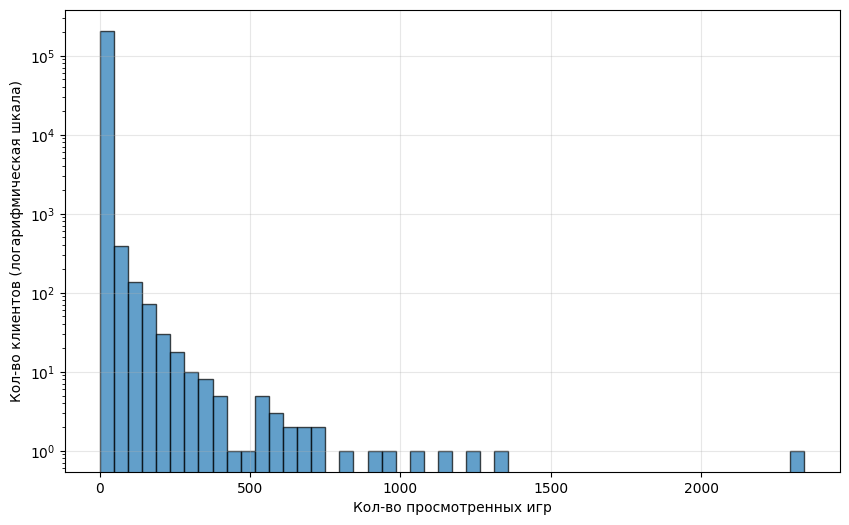

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Получаем данные
value_counts = df_dataset['clientId'].value_counts()

# Строим гистограмму с логарифмической шкалой по оси Y
plt.figure(figsize=(10, 6))
plt.hist(value_counts.values, bins=50, alpha=0.7, edgecolor='black')
plt.yscale('log')
plt.xlabel('Кол-во просмотренных игр')
plt.ylabel('Кол-во клиентов (логарифмическая шкала)')
plt.grid(True, alpha=0.3)
plt.show()

Полагаю, что более 1500 игр для клиента - похоже на выброс.

Думаю, что можно отбросить даже еще чуть-чуть, до 1000 просмотренных игр.

**Первая идея**
Помимо этого, отбросим клиентов, у которых меньше 3 просмотренных игр - нам нужно, хотя бы 2 разные игры в обучающей выборке и хотя бы 1 в тестовой выборке.

Разбивка на трейн и тест придется сделать вручную.

Зададим коэф. деления, скажем, 0.7
В датасете отметим доп.полем факт попадания в сплит, split: 'train' | 'test' | na 

- Если для клиента меньше 3 записей, то игнорируем клиента
- Если у клиента более 1000 записей, игнорируем
- Если для клиента 3 записи, то 2 надо в трейн, 1 в тест
- Если для клиента более 3 записей, то стремимся к тому, чтобы отношение стремилось к заданному (большую часть относим в трейн)

Получается 3 параметра: соотношение сплита, минимум и максимум.

In [ ]:
## pass

**Вторая идея**

Использовать RecTools!

https://github.com/MobileTeleSystems/RecTools/tree/main

Сразу соберу датасет правильно c нужными полями: user_id, item_id, weight, datetime

**Важно**: weight пока равен 1. Надо подумать как его считать из данных метрики!

In [17]:
df_dataset_rt = pd.DataFrame(data, columns=['user_id', 'datetime', 'item_id'])
df_dataset_rt['weight'] = 1

In [18]:
df_dataset_rt.sample(3)

,user_id,datetime,item_id,weight
44670,1699429978625348102,2023-11-08 10:55:47,Elden Ring,1
200086,1691572662723092545,2024-07-25 15:36:58,Cuban Missile Crisis: Ice Crusade,1
152167,1722257055864538439,2024-07-29 15:44:27,Eternity: The Last Unicorn,1


In [19]:
df_dataset_rt.to_csv('./04-metrika-pipeline-dataset-rt.csv')